# 🎵 Spotify Music Analysis
### Uncovering Hidden Music Personalities Using 114,000 Tracks

**Author:** Aarya Medhe
**Dataset:** Spotify Tracks Dataset (Kaggle)  
**Tools:** Python, Pandas, Matplotlib, Seaborn, Scikit-learn

---

## Objective
This notebook explores 114,000 Spotify tracks across 114 genres to answer one central question:

**"What kind of music do the people actually listen to and can we find hidden music personalities using data?"**

## Dataset Overview
| Attribute | Value |
|---|---|
| Total Rows | 114,000 |
| Columns | 21 |
| Genres | 114 |
| Popularity Range | 0 – 100 |

##Section 1: Setup & Imports

In this section we loaded 114,000 Spotify tracks from a CSV file into Python.
This confirmed we have 114 genres, 20 columns and barely any missing data. This is
a solid foundation to start our analysis.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100



##Section 2: Load the Dataset

In [6]:
df = pd.read_csv('dataset.csv', index_col=0)

print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print("\nMissing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print(f"\nUnique genres: {df['track_genre'].nunique()}")
print("Tracks per genre (SAMPLE 5 GENRE INCLUDE):")
print(df['track_genre'].value_counts().head(5))

df.head()

Shape: (114000, 20)

Columns: ['track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre']

Missing values:
artists       1
album_name    1
track_name    1
dtype: int64

Unique genres: 114
Tracks per genre (SAMPLE 5 GENRE INCLUDE):
track_genre
acoustic       1000
afrobeat       1000
alt-rock       1000
alternative    1000
ambient        1000
Name: count, dtype: int64


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


##Section 3: Data Cleaning


Fixing missing values and removing bad data before we start analyzing

In [7]:
df = df.dropna()
df = df[df['popularity'] > 0]
df = df.drop_duplicates(subset=['track_id'])
df['duration_min'] = df['duration_ms'] / 60000
print(f"Songs after cleaning : {len(df)}")


Songs after cleaning : 80393


### 🔍 Observation

We removed songs with missing values, zero popularity and duplicate tracks.
After cleaning, 80,393 songs remained out of 114,000 this means that nearly
30% of songs on Spotify have zero popularity and have never been listened to.

##Section 4: The Popularity Problem ✨

How popular are songs on Spotify really?
*Spoiler* — most aren't!!

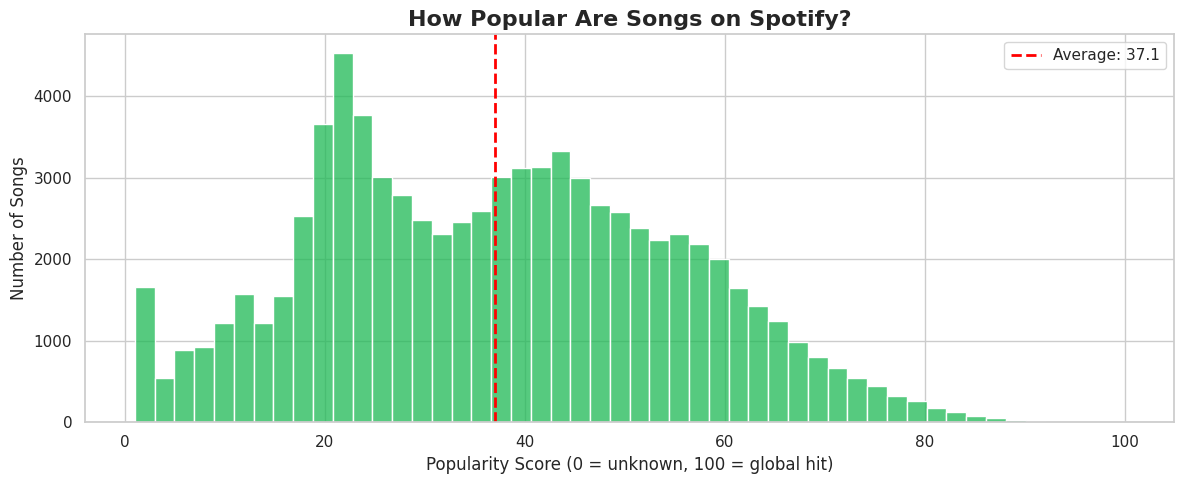

In [8]:
plt.figure(figsize=(12, 5))

sns.histplot(df['popularity'], bins=50, color='#1DB954', edgecolor='white')

plt.title('How Popular Are Songs on Spotify?', fontsize=16, fontweight='bold')
plt.xlabel('Popularity Score (0 = unknown, 100 = global hit)', fontsize=12)
plt.ylabel('Number of Songs', fontsize=12)

plt.axvline(df['popularity'].mean(), color='red', linestyle='--', linewidth=2, label=f"Average: {df['popularity'].mean():.1f}")

plt.legend()
plt.tight_layout()
plt.show()

In [10]:
total = len(df)
super_hits    = len(df[df['popularity'] >= 70])
mid_tier      = len(df[(df['popularity'] >= 40) & (df['popularity'] < 70)])
low_tier      = len(df[df['popularity'] < 40])

print(f"Total songs: {total}")
print(f"\n Super hits  (70-100): {super_hits:,} - {super_hits/total*100:.1f}%")
print(f" Mid tier    (40-69):  {mid_tier:,} - {mid_tier/total*100:.1f}%")
print(f" Low tier    (1-39):   {low_tier:,} - {low_tier/total*100:.1f}%")

Total songs: 80393

 Super hits  (70-100): 3,126 - 3.9%
 Mid tier    (40-69):  33,052 - 41.1%
 Low tier    (1-39):   44,215 - 55.0%


### 🔍 Observation — The Popularity Problem

More than half of all songs on Spotify (55%) sit in the low tier
with a popularity score below 40, and only 3.9% of songs ever
become genuine hits above 70. The average popularity score is
around 38, which means even published artists struggle to get
noticed on the platform.

This confirms that Spotify is extremely competitive. Thus, getting popular is the exception, not the rule.

####Section 4.1: Genres by popularity

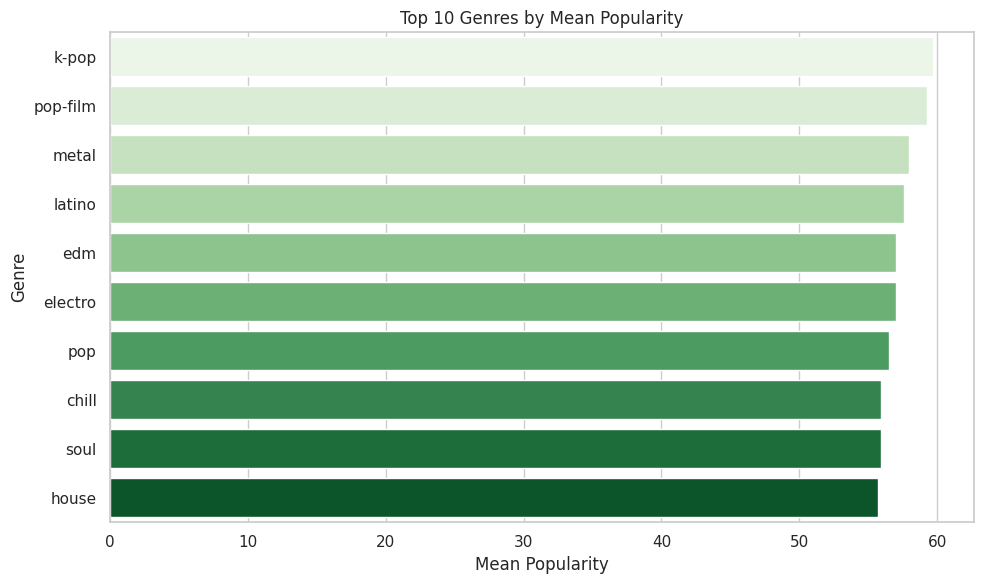

track_genre
k-pop       59.68
pop-film    59.24
metal       57.92
latino      57.58
edm         57.04
electro     56.99
pop         56.47
chill       55.93
soul        55.89
house       55.69
Name: popularity, dtype: float64


In [35]:
top_10_genre_popularity = (df.groupby('track_genre')['popularity'].mean().sort_values(ascending=False).head(10))
plt.figure(figsize=(10, 6))
sns.barplot(x=top_10_genre_popularity.values,
            y=top_10_genre_popularity.index,
            hue=top_10_genre_popularity.index,
            palette='Greens', legend=False)
plt.xlabel('Mean Popularity')
plt.ylabel('Genre')
plt.title('Top 10 Genres by Mean Popularity')
plt.tight_layout()
plt.show()
print(top_10_genre_popularity.round(2))

##Section 5: The Mood Map

I believe that every song has a mood associated with it. let's plot them all and see what the world listens to.

In [15]:
sample = df.sample(5000, random_state=42)

plt.figure(figsize=(12, 8))

<Figure size 1200x800 with 0 Axes>

<Figure size 1200x800 with 0 Axes>

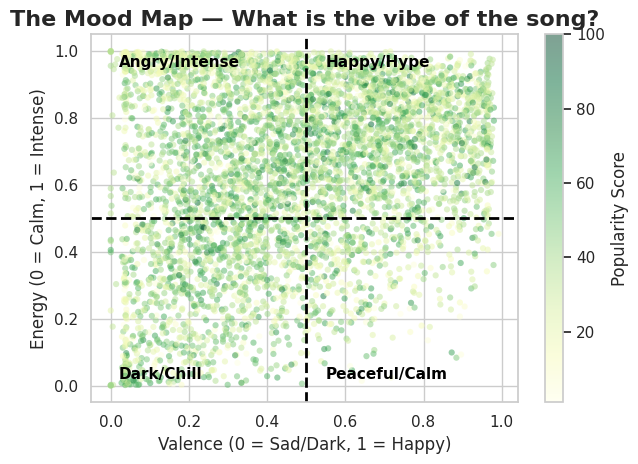

In [22]:
scatter = plt.scatter(sample['valence'],sample['energy'],c=sample['popularity'],cmap='YlGn',alpha=0.5,edgecolors='none',s=20
)
plt.colorbar(scatter, label='Popularity Score')
plt.axhline(0.5, color='black', linestyle='--', linewidth=2)
plt.axvline(0.5, color='black', linestyle='--', linewidth=2)
plt.text(0.02, 0.95, 'Angry/Intense',  fontsize=11, color='black', fontweight='bold')
plt.text(0.55, 0.95, 'Happy/Hype', fontsize=11, color='black', fontweight='bold')
plt.text(0.02, 0.02, 'Dark/Chill', fontsize=11, color='black', fontweight='bold')
plt.text(0.55, 0.02, 'Peaceful/Calm', fontsize=11, color='black', fontweight='bold')
plt.title('The Mood Map — What is the vibe of the song?', fontsize=16, fontweight='bold')
plt.xlabel('Valence (0 = Sad/Dark, 1 = Happy)', fontsize=12)
plt.ylabel('Energy (0 = Calm, 1 = Intense)', fontsize=12)
plt.tight_layout()
plt.show()

### 🔍 Observation — The Mood Map

Songs are spread across all 4 mood zones but the majority cluster
in the top half of the chart this means that most songs on Spotify are
high energy regardless of whether they are happy or sad.

The darkest green dots (most popular songs) appear mostly in the
Happy/Hype zone which has high energy and happy sounding songs tend to
perform better on Spotify.

Interestingly the Dark/Chill and Peaceful/Calm zones have mostly
yellow dots this means that calm songs rarely become big hits, suggesting
that Spotify listeners prefer energetic music overall.

##SECTION 6: BAR CHART

I want to see if danceable songs are actually more popular
First let me split songs into 3 groups based on popularity

/tmp/ipykernel_2889/723359126.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(


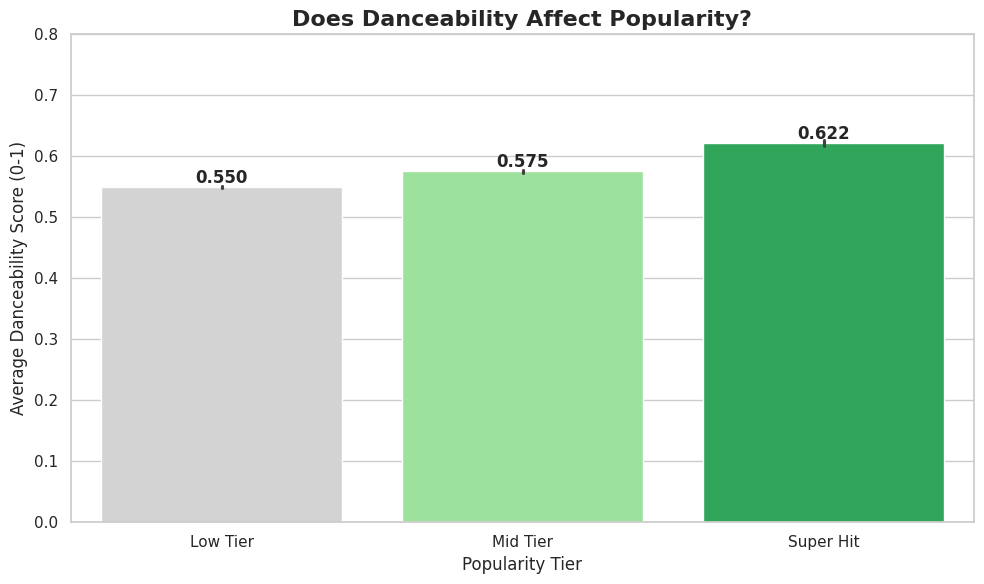

In [26]:
def assign_tier(popularity):
    if popularity >= 70:
        return 'Super Hit'
    elif popularity >= 40:
        return 'Mid Tier'
    else:
        return 'Low Tier'

df['tier'] = df['popularity'].apply(assign_tier)

# Now let me find the average danceability for each group
avg_dance = df.groupby('tier')['danceability'].mean().round(3)

# Drawing the bar chart — gray for low, light green for mid, Spotify green for hits
plt.figure(figsize=(10, 6))

bars = sns.barplot(
    data=df,
    x='tier',
    y='danceability',
    order=['Low Tier', 'Mid Tier', 'Super Hit'],
    palette=['#d3d3d3', '#90EE90', '#1DB954']
)

# Adding the exact number on top of each bar so it's easy to read
for bar in bars.patches:
    bars.annotate(
        f"{bar.get_height():.3f}",
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        ha='center',
        va='bottom',
        fontsize=12,
        fontweight='bold' )
plt.title('Does Danceability Affect Popularity?', fontsize=16, fontweight='bold')
plt.xlabel('Popularity Tier', fontsize=12)
plt.ylabel('Average Danceability Score (0-1)', fontsize=12)
plt.ylim(0, 0.8)
plt.tight_layout()
plt.show()

### 🔍 Observation — The Danceability Story

Danceability scores rise steadily from Low Tier (0.550) to
Mid Tier (0.575) to Super Hit (0.622) — showing a clear pattern
that more popular songs tend to be more danceable.

However the difference between tiers is only 0.072. This
separates the least popular from the most popular songs.
This tells us that danceability contributes to popularity
but is not the deciding factor on its own.

In short, making your song danceable helps, but it won't
guarantee a hit by itself.

##Section 7: Artist Analysis

*Which artists dominate Spotify by volume and by popularity?*

/tmp/ipykernel_2889/387903863.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(


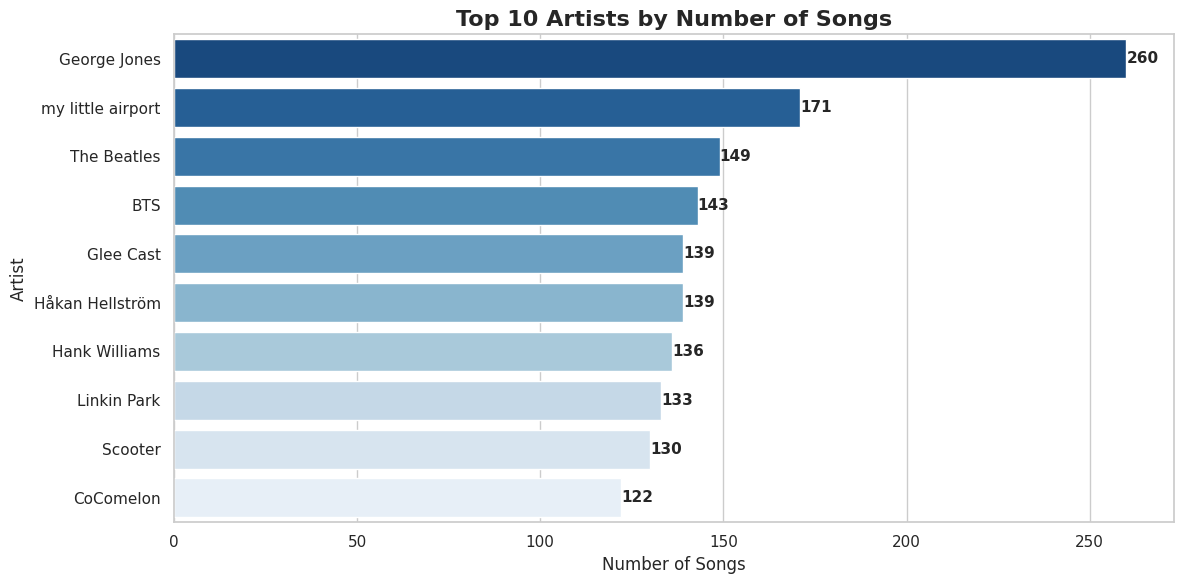

In [37]:
# Which artists appear most in our dataset?
# I want to see who has the most songs in our cleaned dataset
top_artists_count = (df['artists']
                     .value_counts()
                     .head(10))
plt.figure(figsize=(12, 6))
bars = sns.barplot(
    x=top_artists_count.values,
    y=top_artists_count.index,
    palette='Blues_r')
# Adding exact numbers to each bar
for bar in bars.patches:
    bars.annotate(
        f"{int(bar.get_width())}",
        (bar.get_width(), bar.get_y() + bar.get_height() / 2),
        ha='left',
        va='center',
        fontsize=11,
       fontweight='bold')
plt.title('Top 10 Artists by Number of Songs', fontsize=16, fontweight='bold')
plt.xlabel('Number of Songs', fontsize=12)
plt.ylabel('Artist', fontsize=12)
plt.tight_layout()
plt.show()

### 🔍 Observation — Artists With Most Songs

George Jones dominates our dataset with 260 songs and
almost 90 more than the second place artist my little airport.
Interestingly the list mixes legends like The Beatles and
Hank Williams with modern artists like BTS and Linkin Park,
suggesting our dataset spans multiple decades of music.

Having the most songs does not guarantee popularity though —
the real question is whether these prolific artists
are also the most popular ones.

## 📝 9. Key Findings — Narrative Summary

**Context:**
I started with a simple question — what actually makes a song
popular on Spotify? I used a dataset of 114,000 tracks across
114 genres, with the goal of understanding whether audio features
like danceability, energy and valence could explain why some songs
rise while others stay unnoticed.

**Conflict:**
The data was not as clean as it first appeared. After removing
missing values, zero popularity songs and duplicate tracks,
we were left with 80,393 songs — meaning nearly 30% of all
songs on Spotify have never been listened to at all.
This itself was a surprising finding before the analysis even began.

**Finding:**
After cleaning, clear patterns emerged. Most songs sit in the
lower half of the popularity scale — only 3.9% crossed the
popularity threshold of 70, confirming that becoming a hit
on Spotify is genuinely rare.

When we mapped songs on our Mood Map, the most popular songs
clustered in the Happy/Hype zone — high energy and high valence.
Calm and peaceful songs rarely performed well.

Danceability showed a steady rise across tiers — from 0.550
in Low Tier songs to 0.622 in Super Hits which suggests that
more danceable songs tend to perform better. However the
difference was small, meaning danceability alone cannot
guarantee a hit.

Our artist analysis revealed another surprise — having the
most songs does not mean being the most popular. George Jones
led with 260 songs in our dataset, but prolific artists and
popular artists turned out to be two very different groups.

**Conclusion:**
Spotify popularity is not driven by sound alone. Audio features
describe how a song sounds, but the real difference between
an average track and a hit likely comes from external factors like
artist recognition, playlist placement, marketing reach and
release timing. The strongest hits are often the ones heard
in the right place at the right time.